# Задание 7. CpG islands детектор

In [1]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

In [6]:
record = SeqIO.read("/Users/veronikaaksinina/Documents/bioinf_sem_26/chr21.fasta", "fasta")
seq = str(record.seq[5100000:5200000]).upper()

Функция вычисления CpG ratio

In [7]:
def compute_cpg_ratio(window):
    n = len(window)
    if n < 2:
        return None, None

    p_cg = window.count('CG') / (n - 1)
    p_c  = window.count('C') / n
    p_g  = window.count('G') / n
    gc   = (window.count('C') + window.count('G')) / n * 100

    r_cg = p_cg / (p_c * p_g) if p_c > 0 and p_g > 0 else 0

    return r_cg, gc

Сканирование скользящим окном

In [8]:
window_size = 200
positions = []
r_cg_values = []
cpg_islands = []

for i in range(len(seq) - window_size + 1):
    window = seq[i:i + window_size]
    r_cg, gc = compute_cpg_ratio(window)

    positions.append(i)
    r_cg_values.append(r_cg)

    if r_cg > 0.6 and gc > 50:
        cpg_islands.append(i)

print(f"Найдено CpG островков: {len(cpg_islands)}")
print(f"Первые 10 позиций: {cpg_islands[:10]}")

Найдено CpG островков: 6491
Первые 10 позиций: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


Визуализация

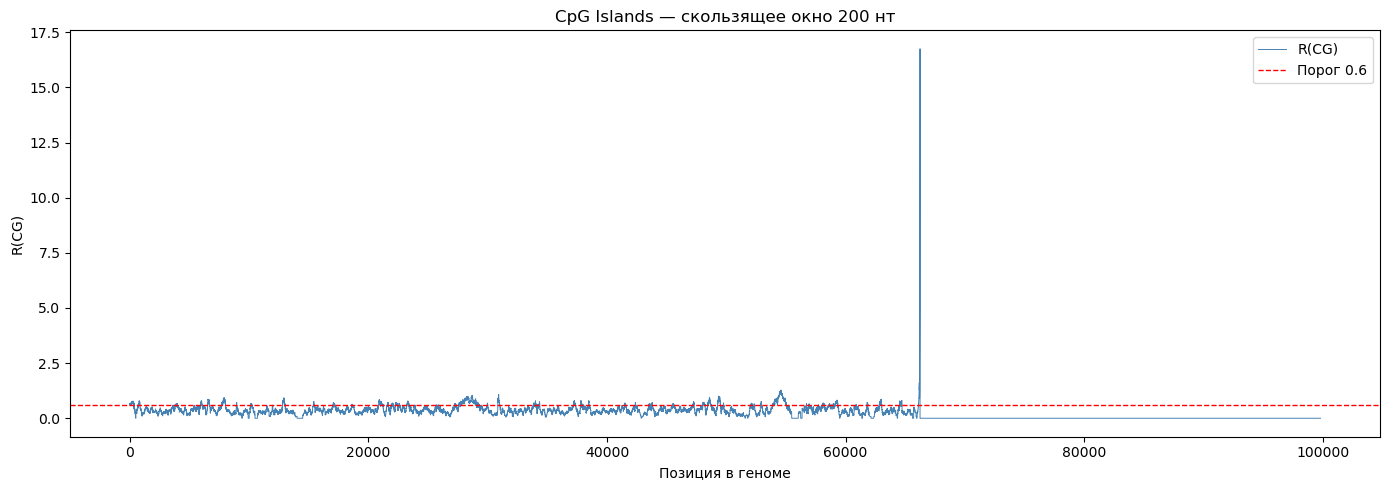

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(positions, r_cg_values, linewidth=0.7, color='steelblue', label='R(CG)')
plt.axhline(y=0.6, color='red', linestyle='--', linewidth=1, label='Порог 0.6')
plt.xlabel('Позиция в геноме')
plt.ylabel('R(CG)')
plt.title('CpG Islands — скользящее окно 200 нт')
plt.legend()
plt.tight_layout()
plt.show()